In [3]:
# Reinstall plotly cleanly
!pip uninstall plotly -y -q
!pip install plotly --upgrade -q

print("✅ Plotly reinstalled!")

✅ Plotly reinstalled!


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import plotly.express as px
import plotly.graph_objects as go

import statsmodels.api as sm
from statsmodels.tsa.seasonal import seasonal_decompose
from sklearn.preprocessing import MinMaxScaler

print("✅ All core libraries imported successfully!")

✅ All core libraries imported successfully!


In [5]:
import pandas as pd

# Load the original file
df = pd.read_csv('city_day.csv')

# Convert Date to datetime
df['Date'] = pd.to_datetime(df['Date'])

# Focus on Delhi and Hyderabad only
cities = ['Delhi', 'Hyderabad']
df_focus = df[df['City'].isin(cities)].copy()

# Sort by City and Date
df_focus = df_focus.sort_values(['City', 'Date']).reset_index(drop=True)

print("✅ Shape of focused data (Delhi + Hyderabad):", df_focus.shape)
print("Date Range:", df_focus['Date'].min(), "to", df_focus['Date'].max())

# Save the focused file
df_focus.to_csv('delhi_hyderabad_air_quality.csv', index=False)
print("✅ File 'delhi_hyderabad_air_quality.csv' saved successfully!")

✅ Shape of focused data (Delhi + Hyderabad): (4015, 16)
Date Range: 2015-01-01 00:00:00 to 2020-07-01 00:00:00
✅ File 'delhi_hyderabad_air_quality.csv' saved successfully!


In [7]:
# Now load the saved file
df = pd.read_csv('delhi_hyderabad_air_quality.csv', parse_dates=['Date'])

print("Shape:", df.shape)
print("Columns:", df.columns.tolist())
print("\nMissing Values in AQI:\n", df['AQI'].isnull().sum())
print("\nFirst 5 rows:\n", df.head())

Shape: (4015, 16)
Columns: ['City', 'Date', 'PM2.5', 'PM10', 'NO', 'NO2', 'NOx', 'NH3', 'CO', 'SO2', 'O3', 'Benzene', 'Toluene', 'Xylene', 'AQI', 'AQI_Bucket']

Missing Values in AQI:
 136

First 5 rows:
     City       Date   PM2.5    PM10     NO    NO2     NOx     NH3     CO  \
0  Delhi 2015-01-01  313.22  607.98  69.16  36.39  110.59   33.85  15.20   
1  Delhi 2015-01-02  186.18  269.55  62.09  32.87   88.14   31.83   9.54   
2  Delhi 2015-01-03   87.18  131.90  25.73  30.31   47.95   69.55  10.61   
3  Delhi 2015-01-04  151.84  241.84  25.01  36.91   48.62  130.36  11.54   
4  Delhi 2015-01-05  146.60  219.13  14.01  34.92   38.25  122.88   9.20   

    SO2     O3  Benzene  Toluene  Xylene    AQI AQI_Bucket  
0  9.25  41.68    14.36    24.86    9.84  472.0     Severe  
1  6.65  29.97    10.55    20.09    4.29  454.0     Severe  
2  2.65  19.71     3.91    10.23    1.99  143.0   Moderate  
3  4.63  25.36     4.26     9.71    3.34  319.0  Very Poor  
4  3.33  23.20     2.80     6.21 

In [ ]:
Step 4: Interactive Visualization + Basic Cleaning + Seasonality Check

In [9]:
import pandas as pd
import numpy as np

# Load the focused dataset
df = pd.read_csv('delhi_hyderabad_air_quality.csv', parse_dates=['Date'])

# Basic cleaning - forward fill missing values within each city
df['AQI'] = df.groupby('City')['AQI'].ffill()

# Fill other important pollutants
pollutants = ['PM2.5', 'PM10', 'NO2', 'SO2', 'CO', 'O3']
for col in pollutants:
    if col in df.columns:
        df[col] = df.groupby('City')[col].ffill()

print("✅ Data loaded and cleaned")
print("Shape:", df.shape)
print("Missing AQI values now:", df['AQI'].isnull().sum())

✅ Data loaded and cleaned
Shape: (4015, 16)
Missing AQI values now: 86


In [ ]:
Interactive AQI Plot

In [13]:
import plotly.io as pio

# Change renderer to avoid extension issues
pio.renderers.default = 'iframe'   # or try 'notebook' or 'iframe_connected'

print("✅ Renderer changed to iframe")

✅ Renderer changed to iframe


In [15]:
fig = px.line(df, x='Date', y='AQI', color='City',
              title='Air Quality Index (AQI) Trend: Delhi vs Hyderabad',
              template='plotly_white')
fig.update_layout(height=650, hovermode='x unified')
fig.show()

In [ ]:
#Step 5: Seasonality Analysis + Anomaly Detection Preparation

<Figure size 1200x1000 with 0 Axes>

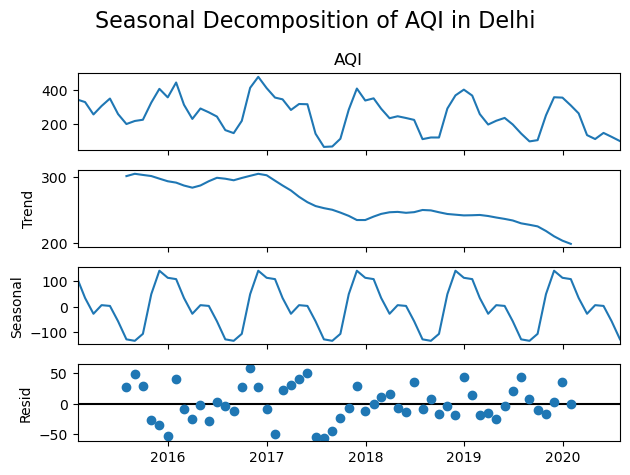

✅ Seasonal Decomposition completed for Delhi


In [17]:
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import seasonal_decompose

# Prepare Delhi data (monthly average for clean decomposition)
delhi = df[df['City'] == 'Delhi'].set_index('Date')
delhi_monthly = delhi['AQI'].resample('M').mean().dropna()

# Seasonal Decomposition
decomp = seasonal_decompose(delhi_monthly, model='additive', period=12)

# Plot
plt.figure(figsize=(12, 10))
decomp.plot()
plt.suptitle('Seasonal Decomposition of AQI in Delhi', fontsize=16)
plt.tight_layout()
plt.show()

print("✅ Seasonal Decomposition completed for Delhi")

In [ ]:
Prepare Data for Anomaly Detection (Z-score Method - Simple but Effective)

In [19]:
# Calculate rolling mean and std for anomaly detection
df['AQI_rolling_mean'] = df.groupby('City')['AQI'].transform(lambda x: x.rolling(window=30, min_periods=1).mean())
df['AQI_rolling_std'] = df.groupby('City')['AQI'].transform(lambda x: x.rolling(window=30, min_periods=1).std())

# Z-score based anomaly detection (threshold = 3)
df['Z_score'] = (df['AQI'] - df['AQI_rolling_mean']) / df['AQI_rolling_std']
df['Anomaly_Z'] = df['Z_score'].abs() > 3

print("✅ Z-score anomaly detection added")
print("Total anomalies detected using Z-score:", df['Anomaly_Z'].sum())
print("\nAnomalies per city:\n", df.groupby('City')['Anomaly_Z'].sum())

✅ Z-score anomaly detection added
Total anomalies detected using Z-score: 40

Anomalies per city:
 City
Delhi        16
Hyderabad    24
Name: Anomaly_Z, dtype: int64


In [ ]:
Step 6: Advanced Anomaly Detection + Visualization

In [21]:
from sklearn.ensemble import IsolationForest
import numpy as np

# Prepare data for Isolation Forest
# We use AQI and a few key pollutants
features = ['AQI', 'PM2.5', 'PM10', 'NO2', 'SO2']
df_model = df[features].fillna(df[features].median())

# Train Isolation Forest
iso_forest = IsolationForest(contamination=0.05, random_state=42)
df['Anomaly_IF'] = iso_forest.fit_predict(df_model)
df['Anomaly_IF'] = df['Anomaly_IF'].map({1: 0, -1: 1})   # 1 = anomaly

print("✅ Isolation Forest completed")
print("Anomalies detected by Isolation Forest:", df['Anomaly_IF'].sum())
print("\nAnomalies per city:\n", df.groupby('City')['Anomaly_IF'].sum())

✅ Isolation Forest completed
Anomalies detected by Isolation Forest: 201

Anomalies per city:
 City
Delhi        179
Hyderabad     22
Name: Anomaly_IF, dtype: int64


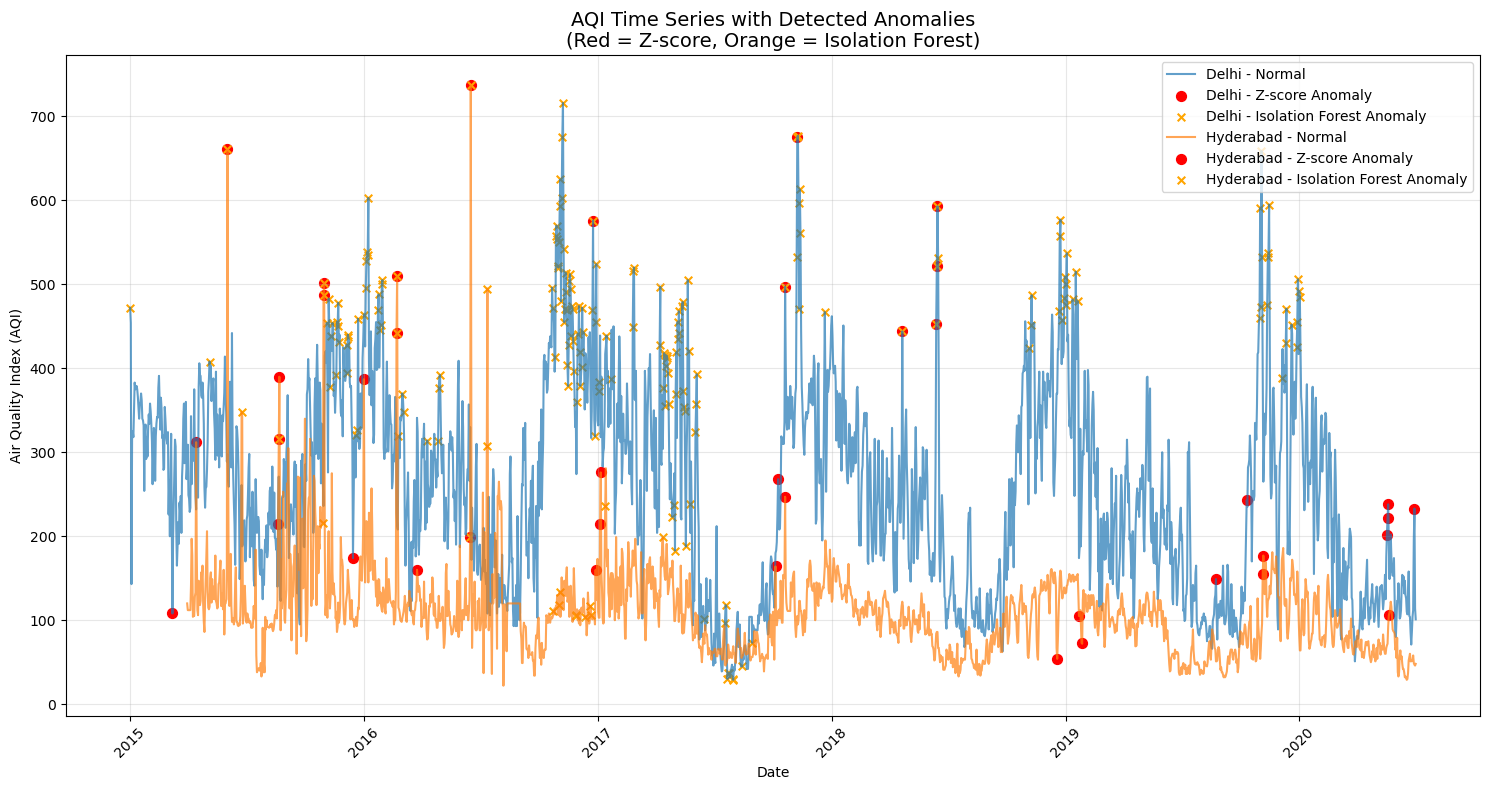

In [23]:
#Visualize Anomalies on Time Series Plot
import matplotlib.pyplot as plt

plt.figure(figsize=(15, 8))

for city in ['Delhi', 'Hyderabad']:
    city_data = df[df['City'] == city]
    
    # Plot normal AQI
    plt.plot(city_data['Date'], city_data['AQI'], label=f'{city} - Normal', alpha=0.7)
    
    # Highlight Z-score anomalies
    anomalies_z = city_data[city_data['Anomaly_Z'] == True]
    plt.scatter(anomalies_z['Date'], anomalies_z['AQI'], color='red', s=50, label=f'{city} - Z-score Anomaly')
    
    # Highlight Isolation Forest anomalies
    anomalies_if = city_data[city_data['Anomaly_IF'] == 1]
    plt.scatter(anomalies_if['Date'], anomalies_if['AQI'], color='orange', s=30, marker='x', label=f'{city} - Isolation Forest Anomaly')

plt.title('AQI Time Series with Detected Anomalies\n(Red = Z-score, Orange = Isolation Forest)', fontsize=14)
plt.xlabel('Date')
plt.ylabel('Air Quality Index (AQI)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [ ]:
Step 7: LSTM Autoencoder (Deep Learning Anomaly Detection)

In [27]:
# Fix protobuf compatibility issue
!pip install protobuf==3.20.3 --force-reinstall -q

print("✅ Protobuf downgraded to compatible version")

✅ Protobuf downgraded to compatible version


  You can safely remove it manually.
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
streamlit 1.37.1 requires packaging<25,>=20, but you have packaging 26.1 which is incompatible.


In [28]:
import numpy as np
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout

# Use Delhi data for LSTM (you can change to Hyderabad later)
delhi_data = df[df['City'] == 'Delhi'].copy()

# Use AQI for simplicity (you can add more features later)
data = delhi_data['AQI'].values.reshape(-1, 1)

# Scale the data
scaler = MinMaxScaler()
data_scaled = scaler.fit_transform(data)

# Create sequences (window size = 30 days)
def create_sequences(data, seq_length=30):
    X = []
    for i in range(len(data) - seq_length):
        X.append(data[i:i + seq_length])
    return np.array(X)

seq_length = 30
X = create_sequences(data_scaled, seq_length)

print("✅ Sequences created for LSTM")
print("Input shape for LSTM:", X.shape)

✅ Sequences created for LSTM
Input shape for LSTM: (1979, 30, 1)


✅ Data loaded successfully!
Shape: (4015, 16)
Date range: 2015-01-01 00:00:00 to 2020-07-01 00:00:00

Missing AQI values after cleaning: 0


C:\Users\boyal\AppData\Local\Temp\ipykernel_16996\1888978770.py:16: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df['AQI'] = df.groupby('City')['AQI'].transform(lambda x: x.fillna(method='ffill').fillna(method='bfill'))


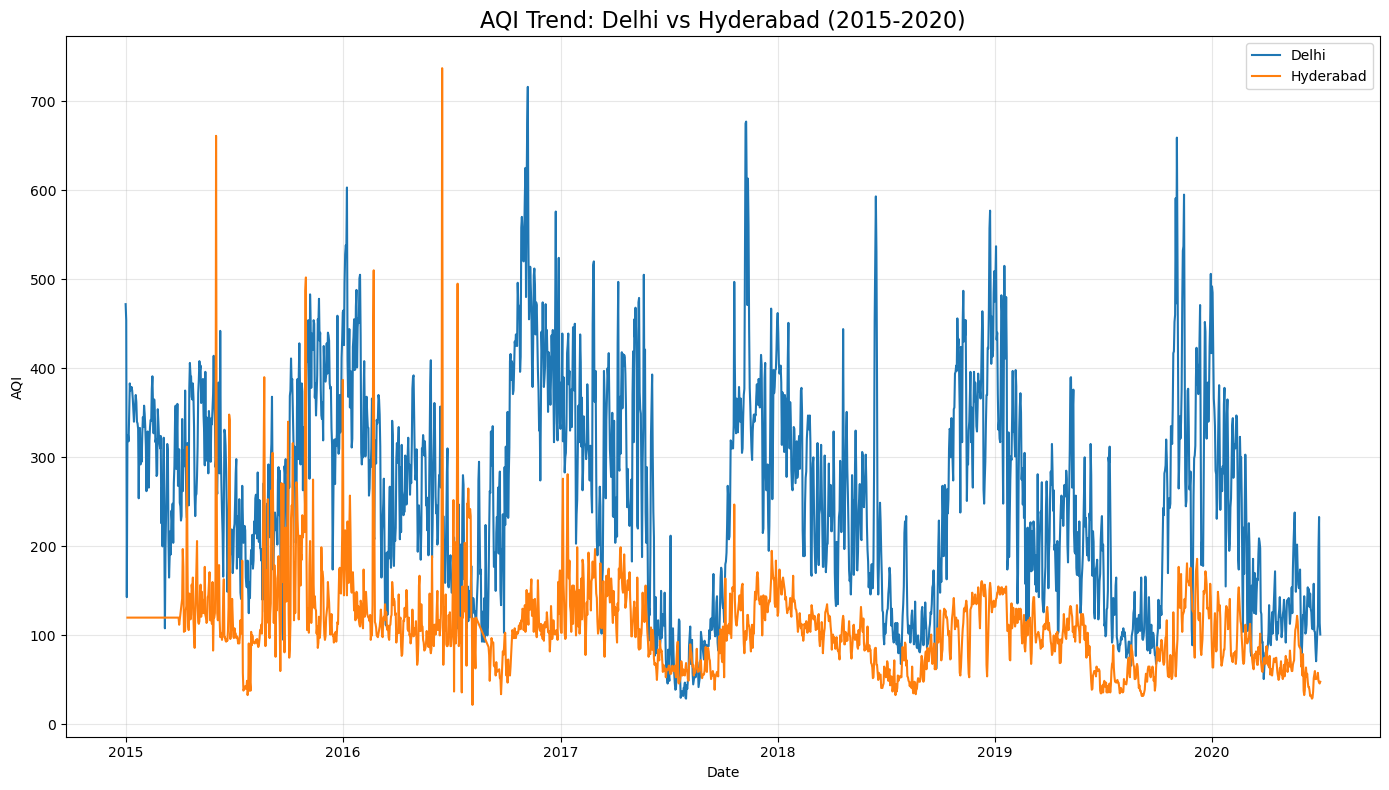

<Figure size 1400x1000 with 0 Axes>

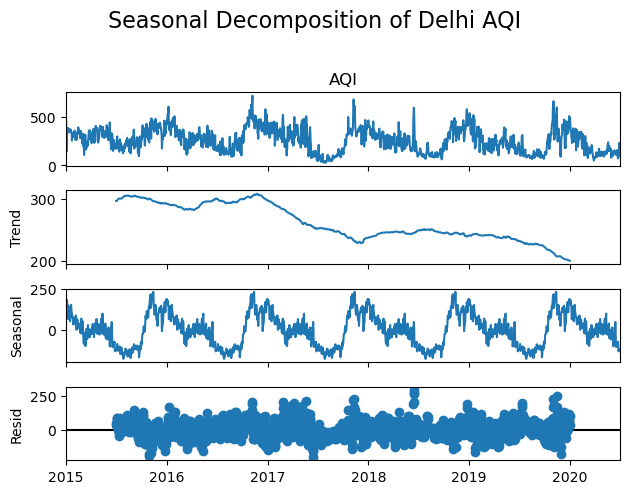

In [31]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.seasonal import seasonal_decompose

# Load the focused data
df = pd.read_csv('delhi_hyderabad_air_quality.csv', parse_dates=['Date'])
df = df.sort_values(['City', 'Date']).reset_index(drop=True)

print("✅ Data loaded successfully!")
print("Shape:", df.shape)
print("Date range:", df['Date'].min(), "to", df['Date'].max())

# Basic cleaning for AQI
df['AQI'] = df.groupby('City')['AQI'].transform(lambda x: x.interpolate(method='linear'))
df['AQI'] = df.groupby('City')['AQI'].transform(lambda x: x.fillna(method='ffill').fillna(method='bfill'))

print("\nMissing AQI values after cleaning:", df['AQI'].isnull().sum())

# Interactive-style plots (static but publication-ready)
plt.figure(figsize=(14, 8))

cities = ['Delhi', 'Hyderabad']
for city in cities:
    city_data = df[df['City'] == city].set_index('Date')
    plt.plot(city_data.index, city_data['AQI'], label=city, linewidth=1.5)

plt.title('AQI Trend: Delhi vs Hyderabad (2015-2020)', fontsize=16)
plt.xlabel('Date')
plt.ylabel('AQI')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Trend & Seasonality Decomposition (for Delhi as example)
delhi_data = df[df['City'] == 'Delhi'].set_index('Date')['AQI'].dropna()

decomp = seasonal_decompose(delhi_data, model='additive', period=365)  # yearly seasonality

plt.figure(figsize=(14, 10))
decomp.plot()
plt.suptitle('Seasonal Decomposition of Delhi AQI', fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

✅ Data Loaded!
Shape: (4015, 16)
Date Range: 2015-01-01 to 2020-07-01

Missing AQI after cleaning: 0


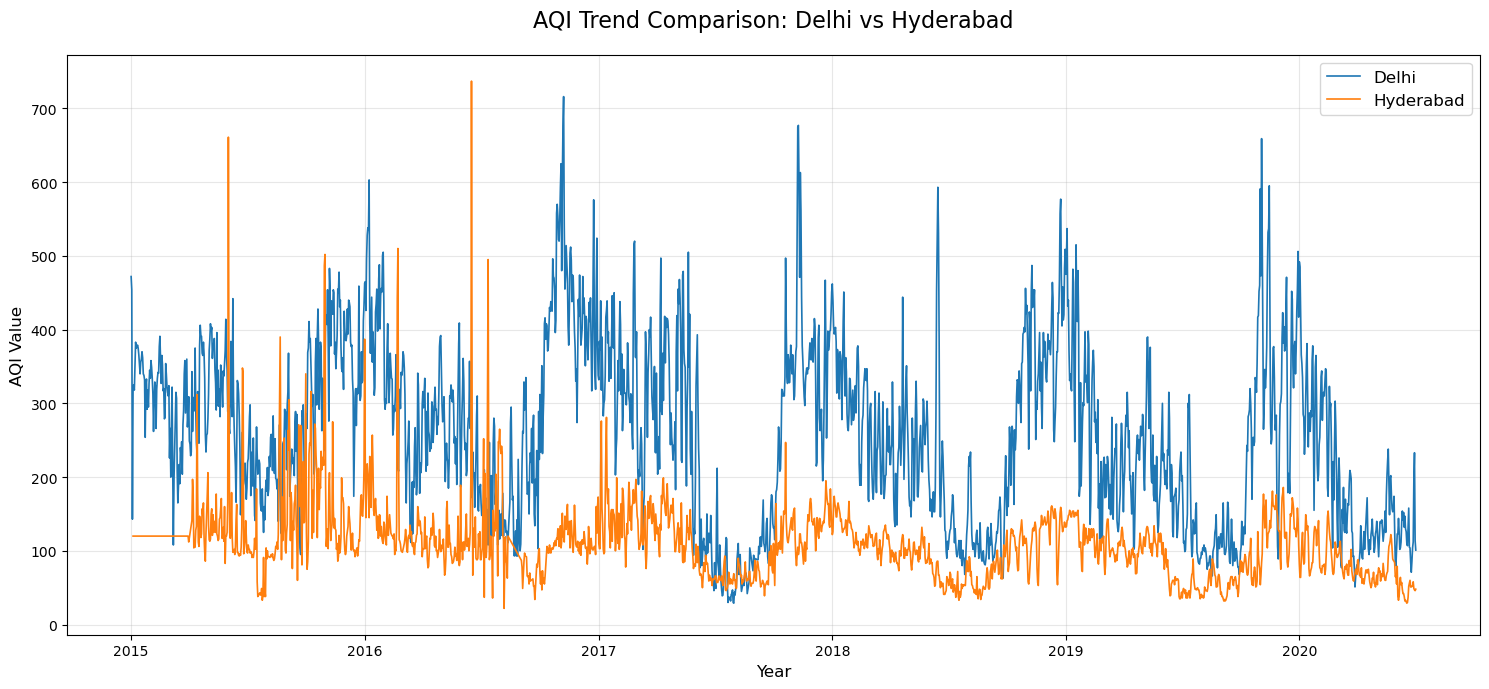

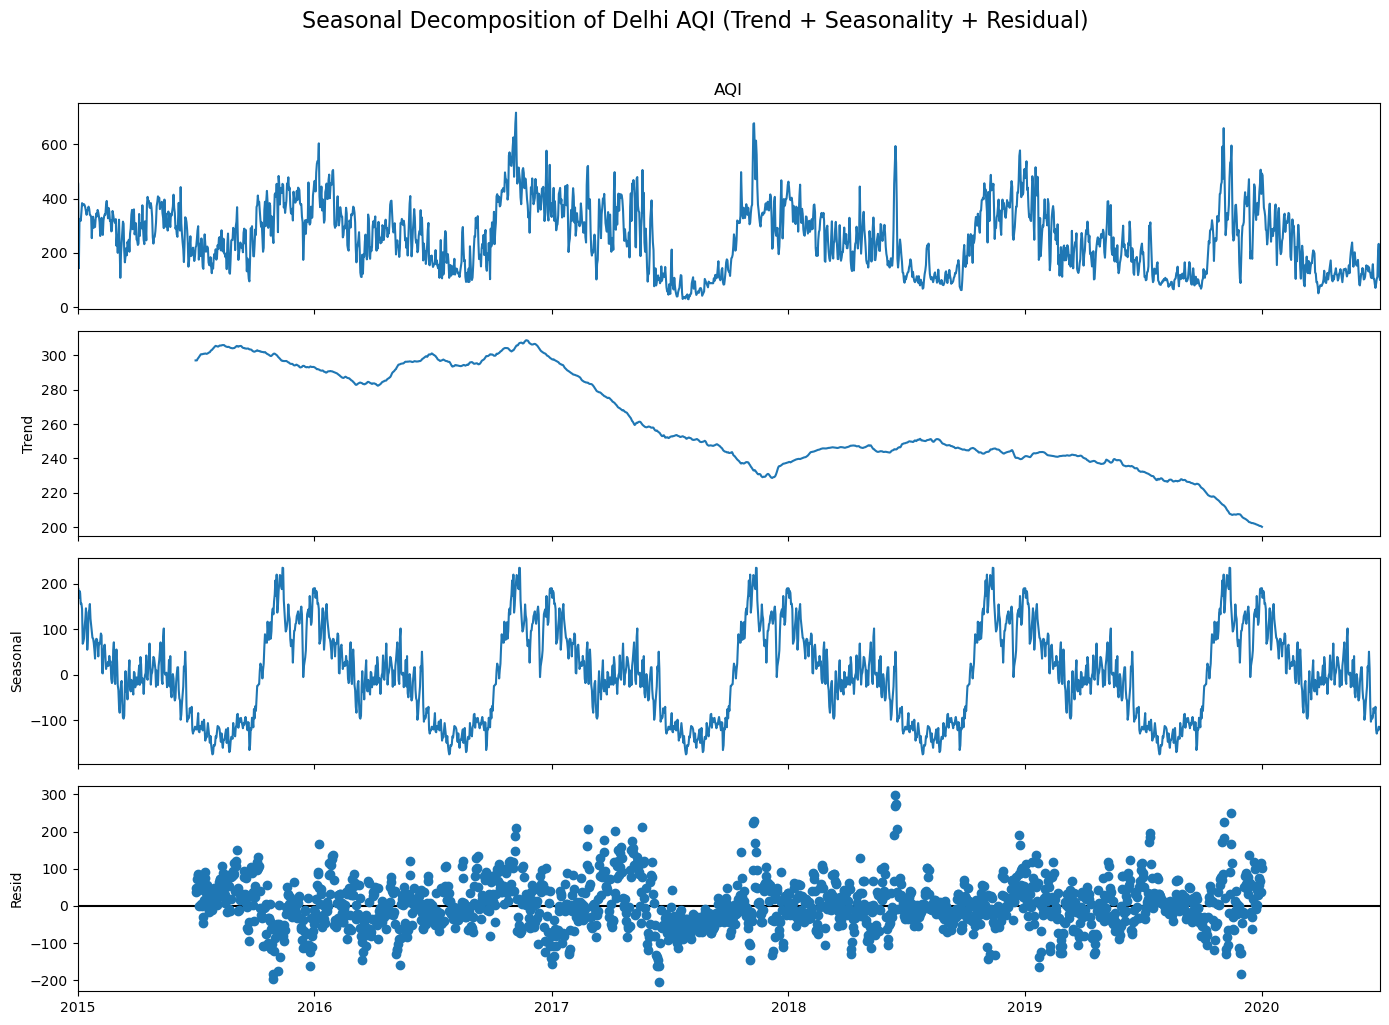


✅ Visualization and cleaning completed!
Next possible steps: Feature Engineering, SARIMA comparison, or Final Report-ready plots.


In [33]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.seasonal import seasonal_decompose
import numpy as np
from sklearn.metrics import mean_absolute_error, mean_squared_error
import warnings
warnings.filterwarnings('ignore')

# ------------------- 1. Load Data -------------------
df = pd.read_csv('delhi_hyderabad_air_quality.csv', parse_dates=['Date'])
df = df.sort_values(['City', 'Date']).reset_index(drop=True)

print("✅ Data Loaded!")
print("Shape:", df.shape)
print("Date Range:", df['Date'].min().date(), "to", df['Date'].max().date())

# ------------------- 2. Basic Cleaning -------------------
# Interpolate missing AQI within each city
df['AQI'] = df.groupby('City')['AQI'].transform(lambda x: x.interpolate(method='linear'))

# Forward and backward fill remaining gaps
df['AQI'] = df.groupby('City')['AQI'].transform(lambda x: x.ffill().bfill())

print("\nMissing AQI after cleaning:", df['AQI'].isnull().sum())

# ------------------- 3. Trend Visualization -------------------
plt.figure(figsize=(15, 7))
for city in ['Delhi', 'Hyderabad']:
    city_data = df[df['City'] == city].set_index('Date')
    plt.plot(city_data.index, city_data['AQI'], label=city, linewidth=1.2)

plt.title('AQI Trend Comparison: Delhi vs Hyderabad', fontsize=16, pad=20)
plt.xlabel('Year', fontsize=12)
plt.ylabel('AQI Value', fontsize=12)
plt.legend(fontsize=12)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# ------------------- 4. Seasonal Decomposition (Delhi) -------------------
delhi_aqi = df[df['City'] == 'Delhi'].set_index('Date')['AQI'].dropna()

decomp = seasonal_decompose(delhi_aqi, model='additive', period=365)

fig = decomp.plot()
fig.set_size_inches(14, 10)
plt.suptitle('Seasonal Decomposition of Delhi AQI (Trend + Seasonality + Residual)', fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

# ------------------- 5. Quick LSTM Evaluation (if you have predictions) -------------------
# Replace this section with your actual LSTM prediction variables
# Example (update with your real y_test and y_pred):

# y_test = ...     # your actual test values
# y_pred = ...     # your LSTM predictions

# if 'y_test' in locals() and 'y_pred' in locals():
#     mae = mean_absolute_error(y_test, y_pred)
#     rmse = np.sqrt(mean_squared_error(y_test, y_pred))
#     print(f"\n📊 LSTM Performance:")
#     print(f"MAE  : {mae:.2f}")
#     print(f"RMSE : {rmse:.2f}")
# else:
#     print("\n⚠️  Add your y_test and y_pred here for evaluation")

print("\n✅ Visualization and cleaning completed!")
print("Next possible steps: Feature Engineering, SARIMA comparison, or Final Report-ready plots.")